## 1. Read data

### 1.1. The dataset of sentences

In [1]:
import pandas as pd
sentence_df = pd.read_excel("/workspace/mijnidbcoachnlp/data/analysis_datasets/translated_sentence_data.xlsx")

In [2]:
sentences = sentence_df["Clean_Sentence"].to_list()

### 1.2. Import list of stopwords

In [3]:
### Importing the list of Dutch stopwords (note that there are customized dutch words in there)

with open('/workspace/mijnidbcoachnlp/data/analysis_datasets/stopwords.txt', 'r') as file:
    lines = [line.strip() for line in file.readlines()]

dutch_stopwords = lines

extra_list = [
    'maandag', 'dinsdag', 'woensdag', 'donderdag', 'vrijdag', 'zaterdag', 'zondag',
    'januari', 'februari', 'maart', 'april', 'mei', 'juni', 'juli', 'augustus', 'september', 'oktober', 'november', 'december',
    'jan', 'feb', 'mrt', 'apr', 'mei', 'jun', 'jul', 'aug', 'sep', 'okt', 'nov', 'dec'
]

dutch_stopwords.extend(extra_list)

## 2. Download the embedding model BERTje

### 2.1 Download BERTje

In [4]:
from transformers.pipelines import pipeline
from transformers import AutoTokenizer, AutoModel, TFAutoModel
embedding_model = pipeline("feature-extraction", model="GroNLP/bert-base-dutch-cased")

Some weights of BertModel were not initialized from the model checkpoint at GroNLP/bert-base-dutch-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### 2.2 Pre-calculate and save sentence embeddings (skip if there are saved embeddings and go to 2.3)

In [ ]:
# pre-calculate the embeddings of the dutch sentences
import numpy as np

embeddings_nl = embedding_model(sentences, truncation=True, padding=True)
sentence_embeddings_nl = np.array([np.mean(embedding, axis=1).flatten() for embedding in embeddings_nl])

In [ ]:
# save the sentence embeddings
import numpy as np
np.save('/workspace/mijnidbcoachnlp/saved_models/sentence_embeddings_bertje_nl.npy', sentence_embeddings_nl)

### 2.3 Load saved embeddings

In [5]:
# load the save model
import numpy as np

loaded_embeddings_nl = np.load('/workspace/mijnidbcoachnlp/data/embeddings/sentence_embeddings_bertje_nl.npy')

In [6]:
embeddings=loaded_embeddings_nl

## 3. Preparation for Fine-Tuning Hyperparameters

### 3.1. Generate a list of hyperparameter combinations

In [7]:
import itertools

# Generating a list of hyperparameter combinations
# UMAP hyperparameters
n_neighbors_values = [5, 10, 15, 20, 25, 30] # we are aiming for strict clusters so the n_neighbors range is relatively small
n_components_values = [2, 3, 4, 5]

# HDBSCAN hyperparameters
min_cluster_size_values = [10, 15, 20, 30]
min_samples_values = [5, 10, 15, 20, 30]

combinations = list(itertools.product(n_neighbors_values, n_components_values, min_cluster_size_values, min_samples_values))

# set min_samples < min_cluster_size
filtered_combinations = [
    combination for combination in combinations if combination[3] <= combination[2] 
]

# print the total number of combinations
len(filtered_combinations)

336

### 3.2 Function to calculate intra-topic similarity

In [8]:
from sklearn.metrics.pairwise import cosine_similarity

# function to calculate intra-topic cosine similarity
def calculate_intra_topic_cosine_similarity(embeddings, doc_topics):
    topic_similarities = []
    
    for topic in set(doc_topics):
        if topic == -1:  # Skip the "outlier" topic
            continue
        
        # Get embeddings of documents in the current topic
        topic_embeddings = embeddings[np.array(doc_topics) == topic]
        
        if len(topic_embeddings) < 2:
            continue  # Skip topics with a single document
        
        # Calculate cosine similarities and average them
        cosine_sim = cosine_similarity(topic_embeddings)
        avg_cosine_sim = cosine_sim[np.triu_indices_from(cosine_sim, k=1)].mean()
        
        topic_similarities.append(avg_cosine_sim)

    return topic_similarities

### 3.3. Function to calculate silhouette scores

In [ ]:
# function to calculate silhouette scores if needed (we don't use the silhouette scores for now because the clusters are probably overlapping a lot so inter-topic distance is not so informative)
from sklearn.metrics import silhouette_samples
import numpy as np

def calculate_intra_topic_silhouette_score(embeddings, topics):

    # Filter out documents assigned to the outlier topic (-1)
    mask = topics != -1
    filtered_embeddings = embeddings[mask]
    filtered_topics = topics[mask]

    # Compute silhouette scores
    silhouette_scores = silhouette_samples(filtered_embeddings, filtered_topics, metric="cosine")
    
    # Calculate average silhouette score for each topic
    unique_topics = np.unique(filtered_topics)
    avg_silhouette_per_topic = {
        topic: np.mean(silhouette_scores[filtered_topics == topic]) for topic in unique_topics
    }

    # Compute the overall average silhouette score across all topics
    avg_silhouette_score = np.mean(list(avg_silhouette_per_topic.values()))

    return avg_silhouette_score


### 3.4 Function to calculate coherence scores

In [42]:
# create the dictionary of documents
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary

def generate_dictionary(documents):

    processed_docs = [doc.split() for doc in documents]
    
    # Create a Gensim dictionary
    dictionary = Dictionary(processed_docs)
    
    return dictionary, processed_docs

dictionary, processed_docs = generate_dictionary(sentences)

In [43]:
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary

def generate_topic_words(topics, top_n_words):
    
    topic_words = []
    
    for topic_num, words in topics.items():
        if topic_num == -1:  # Skip the outlier topic
            continue
        # Collect only the top N words for each topic
        top_words = [word for word, _ in words[:top_n_words]]
        topic_words.append(top_words)
    
    return topic_words

def calculate_coherence_score(topics, dictionary, processed_docs, coherence='c_v', top_n_words=10):

    topic_words = generate_topic_words(topics, top_n_words)

    coherence_model = CoherenceModel(
        topics=topic_words,
        texts=processed_docs,
        dictionary=dictionary,
        coherence=coherence
    )
    
    # Step 4: Get the coherence score
    coherence_score = coherence_model.get_coherence()
    
    return coherence_score


## 4. Fine-Tune BERTje-HDBSCAN model

### 4.1 Fine-Tuning UMAP hyper parameters

In [53]:
# set the vectorizer model
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_model=CountVectorizer(stop_words=dutch_stopwords, min_df=2, ngram_range=(1, 1), token_pattern=r'\b[a-zA-Z]{2,}\b')


### 4.2 Function to build BERTopic model using a combination of hyperparameters

In [56]:
# build the BERTopic model
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
def build_bertopic(combination):
    n_neighbors, n_components, min_cluster_size, min_samples = combination
    
    topic_model = BERTopic(
        embedding_model=embedding_model,
        umap_model=UMAP(n_neighbors=n_neighbors, n_components=n_components, metric='cosine', random_state=42),
        hdbscan_model=HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples, metric='euclidean', cluster_selection_method='eom', prediction_data=True),
        vectorizer_model=vectorizer_model,
        #nr_topics=50
        top_n_words=10,
        verbose=True
    )
    doc_topics, probs = topic_model.fit_transform(sentences, embeddings)
    return topic_model

# Define a function to process each combination
def process_combination_intra_topic_similarity(combination):
    topic_model = build_bertopic(combination)

    # Train model
    
    topics = topic_model.get_topics()
    
    
    # Compute metrics
    intra_topic_similarity = calculate_intra_topic_cosine_similarity(embeddings, doc_topics)

    return combination, intra_topic_similarity

# Define a function to process each combination and calculate coherence
def process_combination_coherence(combination):
    n_neighbors, n_components, min_cluster_size, min_samples = combination
    
    topic_model = build_bertopic(combination)

    # Train model
    
    topics = topic_model.get_topics()
    
    
    # Compute metrics
    coherence_score = calculate_coherence_score(topics, dictionary, processed_docs, coherence='c_v', top_n_words=10)
    
    return combination, coherence_score


### 4.3 Multiprocess for fine-tuning

In [11]:
# function to divide inputs in chunks
def chunk_list(data, chunk_size):
    for i in range(0, len(data), chunk_size):
        yield data[i:i + chunk_size]

In [12]:
# divide filtered_combinations in batches
batch_size = 20

batches = list(chunk_list(filtered_combinations, batch_size))

len(batches) # there are 17 batches

17

In [13]:
# function to save intermediate batch results
import pickle
import os

def save_batch(batch_results, batch_index):
    filename = f"/workspace/mijnidbcoachnlp/data/result_data/batch_{batch_index}.pkl"
    with open(filename, 'wb') as file:
        pickle.dump(batch_results, file)
    print(f"Batch {batch_index} saved.")


In [22]:
import multiprocessing
import os
num_cores = 64

batch_index=16

with multiprocessing.Pool(processes=num_cores) as pool:
    batch=batches[batch_index]
    print(f"processing batch {batch_index}")
    batch_results = pool.map(process_combination_intra_topic_similarity, batch)
    
    # Save each batch individually
    save_batch(batch_results, batch_index)

    # Close and delete the pool to release resources
    pool.close()
    pool.join()
    del pool  # Delete the pool variable to free memory

IndexError: list index out of range

In [25]:
# Load all batches into a single results list
all_results = []
for batch_index in range(len(batches)):
    with open(f"/workspace/mijnidbcoachnlp/data/result_data/batch_{batch_index}.pkl", 'rb') as file:
        batch_results = pickle.load(file)
        all_results.extend(batch_results)

# Optionally separate into result_combinations and model_topic_similarities
result_combinations, model_topic_similarities = zip(*all_results)

## 5. Compare the intra-topic similarities of the 20 models with the highest intra-topic similarities (both average and spread)

In [36]:
import statistics

# Calculate average and standard deviation for each model
model_stats = [(i, sum(topic_sim) / len(topic_sim), statistics.stdev(topic_sim)) for i, topic_sim in enumerate(model_topic_similarities)]

# Sort models by highest average similarity and then by lowest standard deviation
sorted_models = sorted(model_stats, key=lambda x: (-x[1], x[2]))

# Select the top 20 models (indices, average similarity, and standard deviation)
top_20_models = sorted_models[:20]

# Extract just the indices of the top 20 models if needed
top_20_indices = [model[0] for model in top_20_models]

print("Indices of the top 20 models:", top_20_indices)

Indices of the top 20 models: [291, 265, 249, 208, 248, 330, 162, 246, 334, 307, 302, 306, 320, 137, 204, 250, 321, 329, 288, 333]


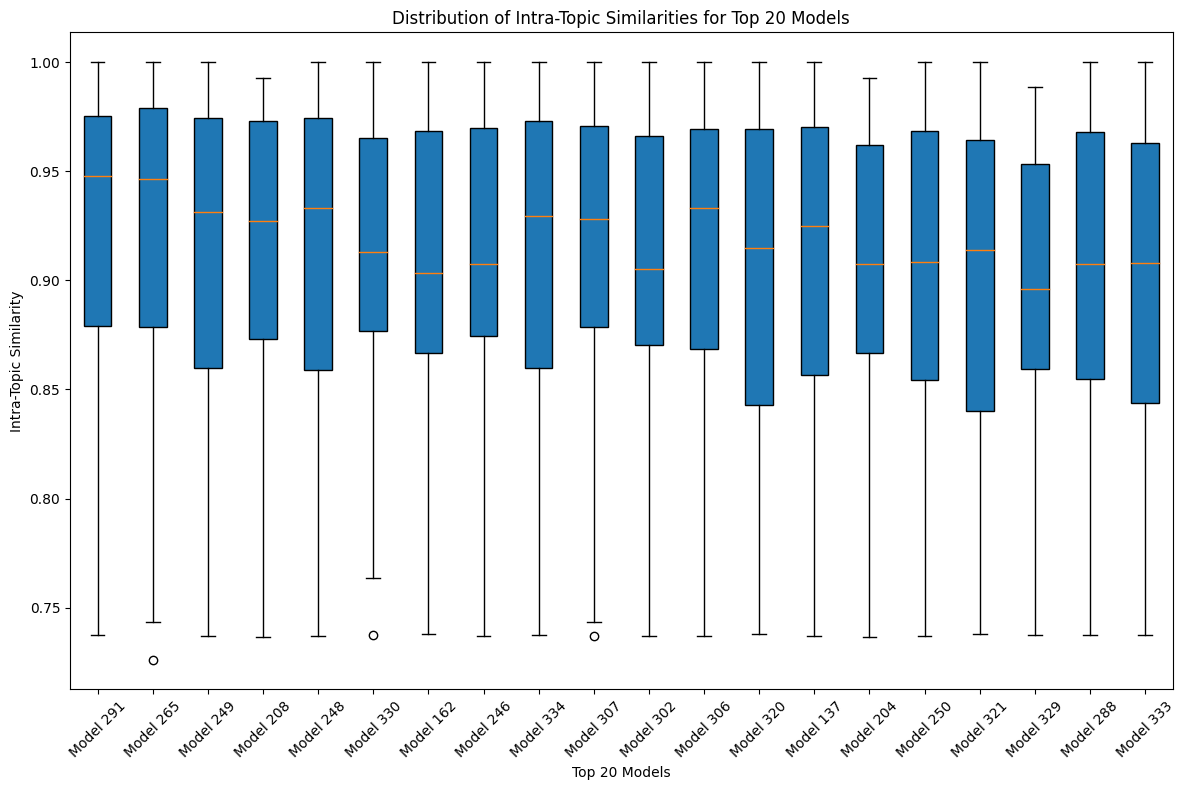

In [35]:
import matplotlib.pyplot as plt

# Assume `top_20_indices` contains the indices of the top 20 models
# and `intra_topic_similarities` is the main list containing similarities for all models

# Extract intra-topic similarities for the top 20 models
top_20_similarities = [model_topic_similarities[i] for i in top_20_indices]

# Plotting
plt.figure(figsize=(12, 8))
plt.boxplot(top_20_similarities, vert=True, patch_artist=True)

# Set x-axis labels and title
plt.xticks(range(1, 21), [f"Model {i}" for i in top_20_indices], rotation=45)
plt.xlabel("Top 20 Models")
plt.ylabel("Intra-Topic Similarity")
plt.title("Distribution of Intra-Topic Similarities for Top 20 Models")

plt.tight_layout()
plt.show()


## 6. Calculate topics coherence scores for these 20 models and choose the top 10 models

In [38]:
# get the hyperparameter combinations of the top 20 models
top_20_combinations = [result_combinations[i] for i in top_20_indices]
top_20_combinations

[(30, 2, 30, 15),
 (25, 4, 30, 30),
 (25, 3, 30, 15),
 (20, 4, 30, 20),
 (25, 3, 30, 10),
 (30, 5, 20, 20),
 (15, 5, 20, 20),
 (25, 3, 20, 20),
 (30, 5, 30, 20),
 (30, 3, 30, 30),
 (30, 3, 20, 20),
 (30, 3, 30, 20),
 (30, 4, 30, 20),
 (15, 3, 30, 15),
 (20, 4, 20, 20),
 (25, 3, 30, 20),
 (30, 4, 30, 30),
 (30, 5, 20, 15),
 (30, 2, 20, 20),
 (30, 5, 30, 15)]

In [48]:
# seems like multiprocessing does not work well for coherence score calculation so we have to do a single thread
coherence_results_20 = []
index = 1
for combination in top_20_combinations:
    print(f"processing {1}")
    index += 1
    coherence_results = process_combination_coherence(combination)
    coherence_results_20.append(coherence_results)

2024-11-06 18:06:52,579 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


processing 1


2024-11-06 18:08:20,759 - BERTopic - Dimensionality - Completed ✓
2024-11-06 18:08:20,763 - BERTopic - Cluster - Start clustering the reduced embeddings
2024-11-06 18:08:22,660 - BERTopic - Cluster - Completed ✓
2024-11-06 18:08:22,662 - BERTopic - Representation - Extracting topics from clusters using representation models.
2024-11-06 18:08:23,532 - BERTopic - Representation - Completed ✓
2024-11-06 18:08:23,534 - BERTopic - Topic reduction - Reducing number of topics
2024-11-06 18:08:23,536 - BERTopic - Topic reduction - Reduced number of topics from 25 to 25
2024-11-06 18:08:34,951 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


processing 1


2024-11-06 18:10:07,903 - BERTopic - Dimensionality - Completed ✓
2024-11-06 18:10:07,906 - BERTopic - Cluster - Start clustering the reduced embeddings
2024-11-06 18:10:11,555 - BERTopic - Cluster - Completed ✓
2024-11-06 18:10:11,557 - BERTopic - Representation - Extracting topics from clusters using representation models.
2024-11-06 18:10:12,421 - BERTopic - Representation - Completed ✓
2024-11-06 18:10:12,422 - BERTopic - Topic reduction - Reducing number of topics
2024-11-06 18:10:12,424 - BERTopic - Topic reduction - Reduced number of topics from 13 to 13
2024-11-06 18:10:28,782 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


...

2024-11-06 18:38:33,131 - BERTopic - Dimensionality - Completed ✓
2024-11-06 18:38:33,136 - BERTopic - Cluster - Start clustering the reduced embeddings
2024-11-06 18:38:37,147 - BERTopic - Cluster - Completed ✓
2024-11-06 18:38:37,149 - BERTopic - Representation - Extracting topics from clusters using representation models.
2024-11-06 18:38:38,121 - BERTopic - Representation - Completed ✓
2024-11-06 18:38:38,123 - BERTopic - Topic reduction - Reducing number of topics
2024-11-06 18:38:39,139 - BERTopic - Topic reduction - Reduced number of topics from 55 to 50
2024-11-06 18:38:53,333 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


processing 1


2024-11-06 18:40:26,301 - BERTopic - Dimensionality - Completed ✓
2024-11-06 18:40:26,304 - BERTopic - Cluster - Start clustering the reduced embeddings
2024-11-06 18:40:28,252 - BERTopic - Cluster - Completed ✓
2024-11-06 18:40:28,253 - BERTopic - Representation - Extracting topics from clusters using representation models.
2024-11-06 18:40:29,211 - BERTopic - Representation - Completed ✓
2024-11-06 18:40:29,213 - BERTopic - Topic reduction - Reducing number of topics
2024-11-06 18:40:29,215 - BERTopic - Topic reduction - Reduced number of topics from 45 to 45
2024-11-06 18:40:45,772 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


processing 1


2024-11-06 18:42:29,265 - BERTopic - Dimensionality - Completed ✓
2024-11-06 18:42:29,269 - BERTopic - Cluster - Start clustering the reduced embeddings
2024-11-06 18:42:33,220 - BERTopic - Cluster - Completed ✓
2024-11-06 18:42:33,223 - BERTopic - Representation - Extracting topics from clusters using representation models.
2024-11-06 18:42:34,180 - BERTopic - Representation - Completed ✓
2024-11-06 18:42:34,182 - BERTopic - Topic reduction - Reducing number of topics
2024-11-06 18:42:34,184 - BERTopic - Topic reduction - Reduced number of topics from 36 to 36


In [49]:
coherence_results_20

[((30, 2, 30, 15), 0.5311942399527642),
 ((25, 4, 30, 30), 0.5358570593772186),
 ((25, 3, 30, 15), 0.5453967479023163),
 ((20, 4, 30, 20), 0.5287952777138237),
 ((25, 3, 30, 10), 0.5518144481281035),
 ((30, 5, 20, 20), 0.554461175806861),
 ((15, 5, 20, 20), 0.5567626277868675),
 ((25, 3, 20, 20), 0.5550747322790982),
 ((30, 5, 30, 20), 0.5236000081227755),
 ((30, 3, 30, 30), 0.5248659590224748),
 ((30, 3, 20, 20), 0.542587743987455),
 ((30, 3, 30, 20), 0.514968176787378),
 ((30, 4, 30, 20), 0.5458461855609099),
 ((15, 3, 30, 15), 0.5744827070510985),
 ((20, 4, 20, 20), 0.5282621954593424),
 ((25, 3, 30, 20), 0.5723501640518464),
 ((30, 4, 30, 30), 0.5574663126882713),
 ((30, 5, 20, 15), 0.5564664748399827),
 ((30, 2, 20, 20), 0.5360402671755775),
 ((30, 5, 30, 15), 0.5495539759099876)]

In [58]:
combination = (5, 2, 10, 5)
topic_model = build_bertopic(combination)
topics, probs = topic_model.fit_transform(sentences, embeddings)



2024-11-06 18:55:03,428 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2024-11-06 18:55:34,656 - BERTopic - Dimensionality - Completed ✓
2024-11-06 18:55:34,660 - BERTopic - Cluster - Start clustering the reduced embeddings
2024-11-06 18:55:37,046 - BERTopic - Cluster - Completed ✓
2024-11-06 18:55:37,066 - BERTopic - Representation - Extracting topics from clusters using representation models.
2024-11-06 18:55:38,765 - BERTopic - Representation - Completed ✓


In [61]:
doc_topics = topic_model.get_document_info(sentences)["Topic"].to_list()
intra_topic_similarity = calculate_intra_topic_cosine_similarity(embeddings, doc_topics)
intra_topic_similarity

[0.8374381818610173,
 0.8117083813941119,
 0.805897035248446,
 0.8155262445547375,
 0.7977537793851515,
 0.875173607623192,
 0.8098209440080757,
 0.7905666724308917,
 0.8015684665331474,
 0.7793739140467681,
 0.8122891159676101,
 0.8055425415759058,
 0.7793374594687549,
 0.8046796234900587,
 0.8094741198947841,
 0.8076265098230755,
 0.8456978876680529,
 0.7972780486114351,
 0.816698366227791,
 0.781874294761998,
 0.87284901241858,
 0.8190619847095981,
 0.8346517217533145,
 0.7951912654671673,
 0.8216213079768295,
 0.809889195538965,
 0.748740984379616,
 0.8135683024428331,
 0.8056218390431905,
 0.8060974145888079,
 0.7883230892037489,
 0.7579620531740432,
 0.7813075560296655,
 0.8085156782591427,
 0.7913984935509831,
 0.8609267342924061,
 0.795900088151142,
 0.7806901019135071,
 0.7759432363962603,
 0.8118670110819256,
 0.7918470999095197,
 0.7830067098884254,
 0.8118231074973997,
 0.771193103664119,
 0.8382640391041098,
 0.803967880979159,
 0.8536863103466805,
 0.8330096870115545,
 0.

In [64]:
topic_model.reduce_topics(nr_topics=50, docs=sentences)
topic_model.get_topic_info()

2024-11-06 18:59:20,535 - BERTopic - Topic reduction - Reducing number of topics
2024-11-06 18:59:21,336 - BERTopic - Topic reduction - Reduced number of topics from 973 to 50


,Topic,Count,Name,Representation,Representative_Docs
0,-1,15600,-1_ontlasting_afspraak_week_bloed,"[ontlasting, afspraak, week, bloed, goed, weke...","[Op 12 april had ik de laatste afspraak met , ..."
1,0,21603,0_ontlasting_bloed_afspraak_laten,"[ontlasting, bloed, afspraak, laten, week, zie...",[Ik heb op bloed laten prikken maar nog geen ...
2,1,1326,1_bedankt_reactie_snelle_dank,"[bedankt, reactie, snelle, dank, bericht, alva...","[Bedankt voor de snelle reactie., Bedankt voor..."
3,2,495,2_alvast_bedankt_dankjewel_dank,"[alvast, bedankt, dankjewel, dank, fijn, harte...","[Jullie zijn alvast bedankt., 06-[ID] Alvast ..."
4,3,349,3_fijn_horen_goed_prima,"[fijn, horen, goed, prima, ok, doorgefaxt, uit...","[Dat is fijn om te horen., Fijn om te horen., ..."
5,4,345,4_hoor_graag_vr_raadhuisplein,"[hoor, graag, vr, raadhuisplein, rechtstreeks,...","[Ik hoor het graag., Ik hoor het graag van u.,..."
6,5,274,5_advies_adviseren_beste_verwachten,"[advies, adviseren, beste, verwachten, oplosse...","[Wat is jullie advies hierin?, Wat is jullie a..."
7,6,212,6_vraag_vraagje_vragen_daarnaast,"[vraag, vraagje, vragen, daarnaast, vraagjes, ...","[Even nog een andere vraag., Verder heb ik nog..."
8,7,188,7_zorgen_weet_voel_echt,"[zorgen, weet, voel, echt, goed, blij, moedelo...","[maar mij echter wel zorgen over mijzelf., Daa..."
9,8,180,8_zorginstelling_apotheek_gefaxt_recept,"[zorginstelling, apotheek, gefaxt, recept, stu...","[Mijn apotheek is [ZORGINSTELLING]., Mijn apot..."
